# Mod 7 L3 Code Assignment: AI Assisted Workflows (Brainstorm)

### Goal: 
Practice writing reliable prompts for parts of the data modeling lifecycle (EDA, Modeling,Verification, Deployment).
### Dataset context: 
Python built-in diamonds dataset in seaborn package.
### Model context: 
Multiple Linear Regression on price of diamond

**You all will do this as a class coming up with your OWN prompts**

## WE ALL DO 

### **15 Minutes**:  Explore the data focus on answering the following questions

- Anything about the data look strange?
- Are there any features AI should include in predicting price? 
- Are there any features that shouldn't be in the same model due to assumptions?
- If running a linear regression to predict price, how should the model be evaluate (which metric makes sense)?
- What are some code checks you would do along the way?


In [1]:
import seaborn as sns
import pandas as pd
import numpy as np


In [2]:
df = sns.load_dataset("diamonds")

# Add cells below to answer this sections questions 
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


### 8 minutes: EDA Prompt (copy AI output below this cell)

Come up with an EDA prompt that is specific.   

You should tell AI what exact charts to create (for example don't assume it knows the best datatypes for a scatterplot you should tell it)

In addition to visuals, you need a prompt that explores other important features about the data

AI Input: Perform EDA on df


Shape: (53940, 10)

Data types:
 carat       float64
cut        category
color      category
clarity    category
depth       float64
table       float64
price         int64
x           float64
y           float64
z           float64
dtype: object

Missing values:
 carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

Duplicate rows: 146

Basic stats (numeric):
          count         mean          std    min     25%      50%      75%  \
carat  53940.0     0.797940     0.474011    0.2    0.40     0.70     1.04   
depth  53940.0    61.749405     1.432621   43.0   61.00    61.80    62.50   
table  53940.0    57.457184     2.234491   43.0   56.00    57.00    59.00   
price  53940.0  3932.799722  3989.439738  326.0  950.00  2401.00  5324.25   
x      53940.0     5.731157     1.121761    0.0    4.71     5.70     6.54   
y      53940.0     5.734526     1.142135    0.0    4.72     5.71     6.54   
z      

,carat,cut,color,clarity,depth,table,price,x,y,z
2207,1.00,Premium,G,SI2,59.1,59.0,3142,6.55,6.48,0.0
2314,1.01,Premium,H,I1,58.1,59.0,3167,6.66,6.60,0.0
4791,1.10,Premium,G,SI2,63.0,59.0,3696,6.50,6.47,0.0
5471,1.01,Premium,F,SI2,59.2,58.0,3837,6.50,6.47,0.0
10167,1.50,Good,G,I1,64.0,61.0,4731,7.15,7.04,0.0



Skewness (numeric):
 y        2.434167
price    1.618395
z        1.522423
carat    1.116646
table    0.796896
x        0.378676
depth   -0.082294
dtype: float64

Correlation with price:
 price    1.000000
carat    0.921591
x        0.884435
y        0.865421
z        0.861249
table    0.127134
depth   -0.010647
Name: price, dtype: float64


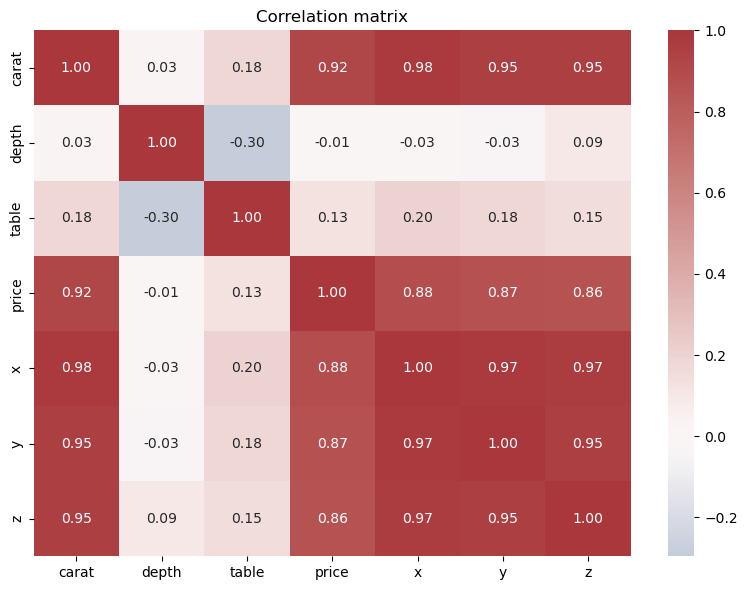

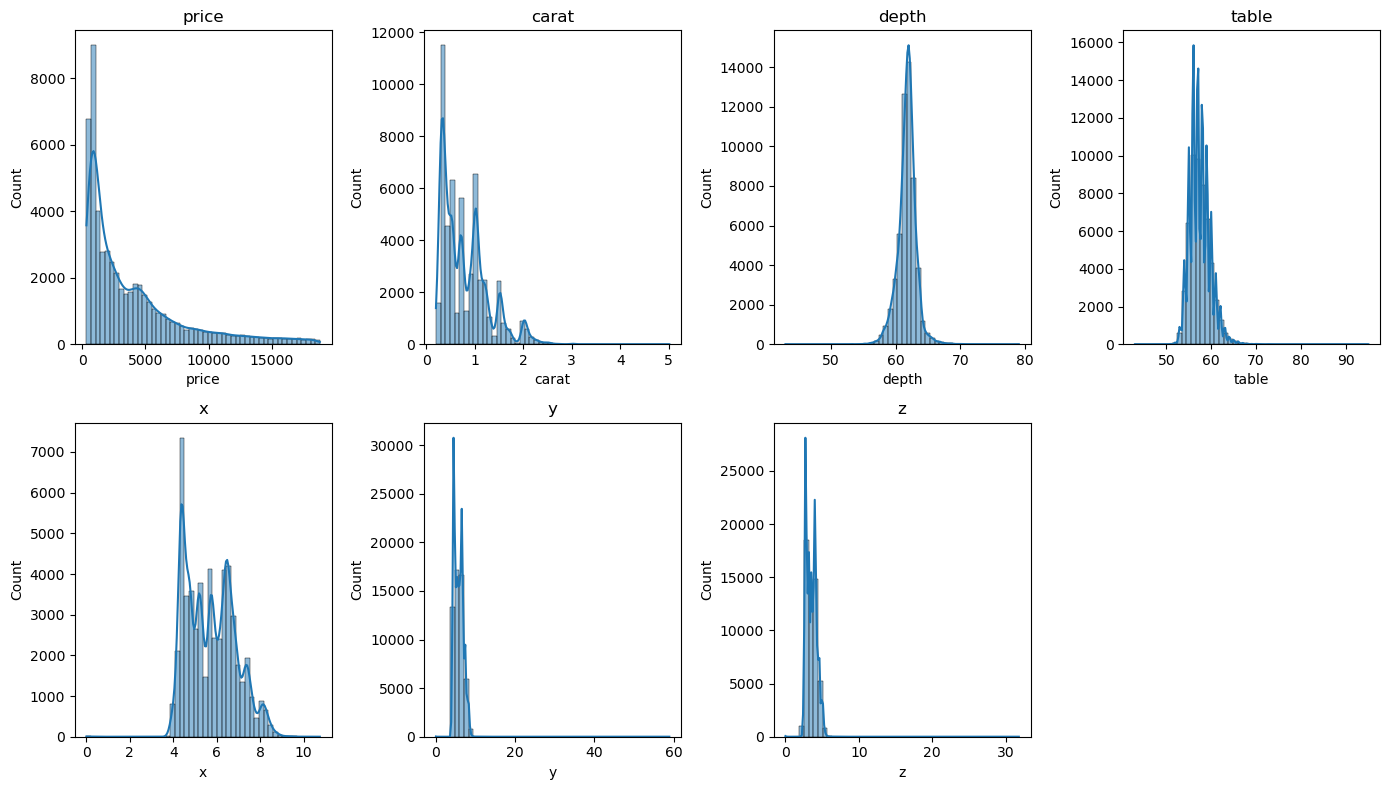

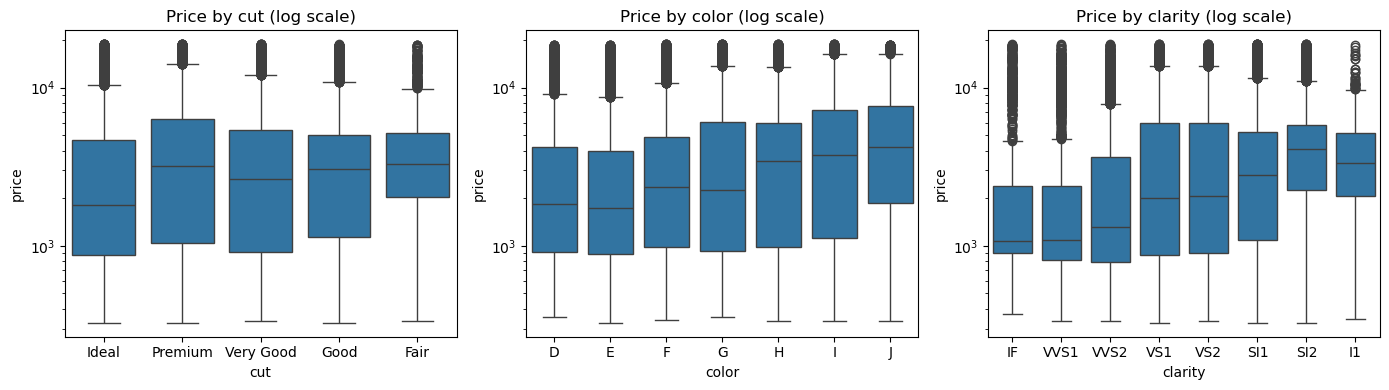

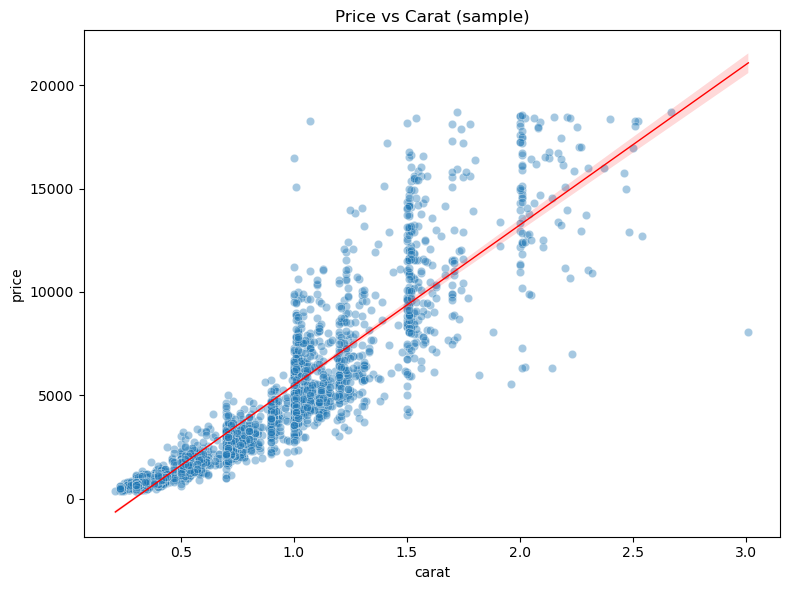

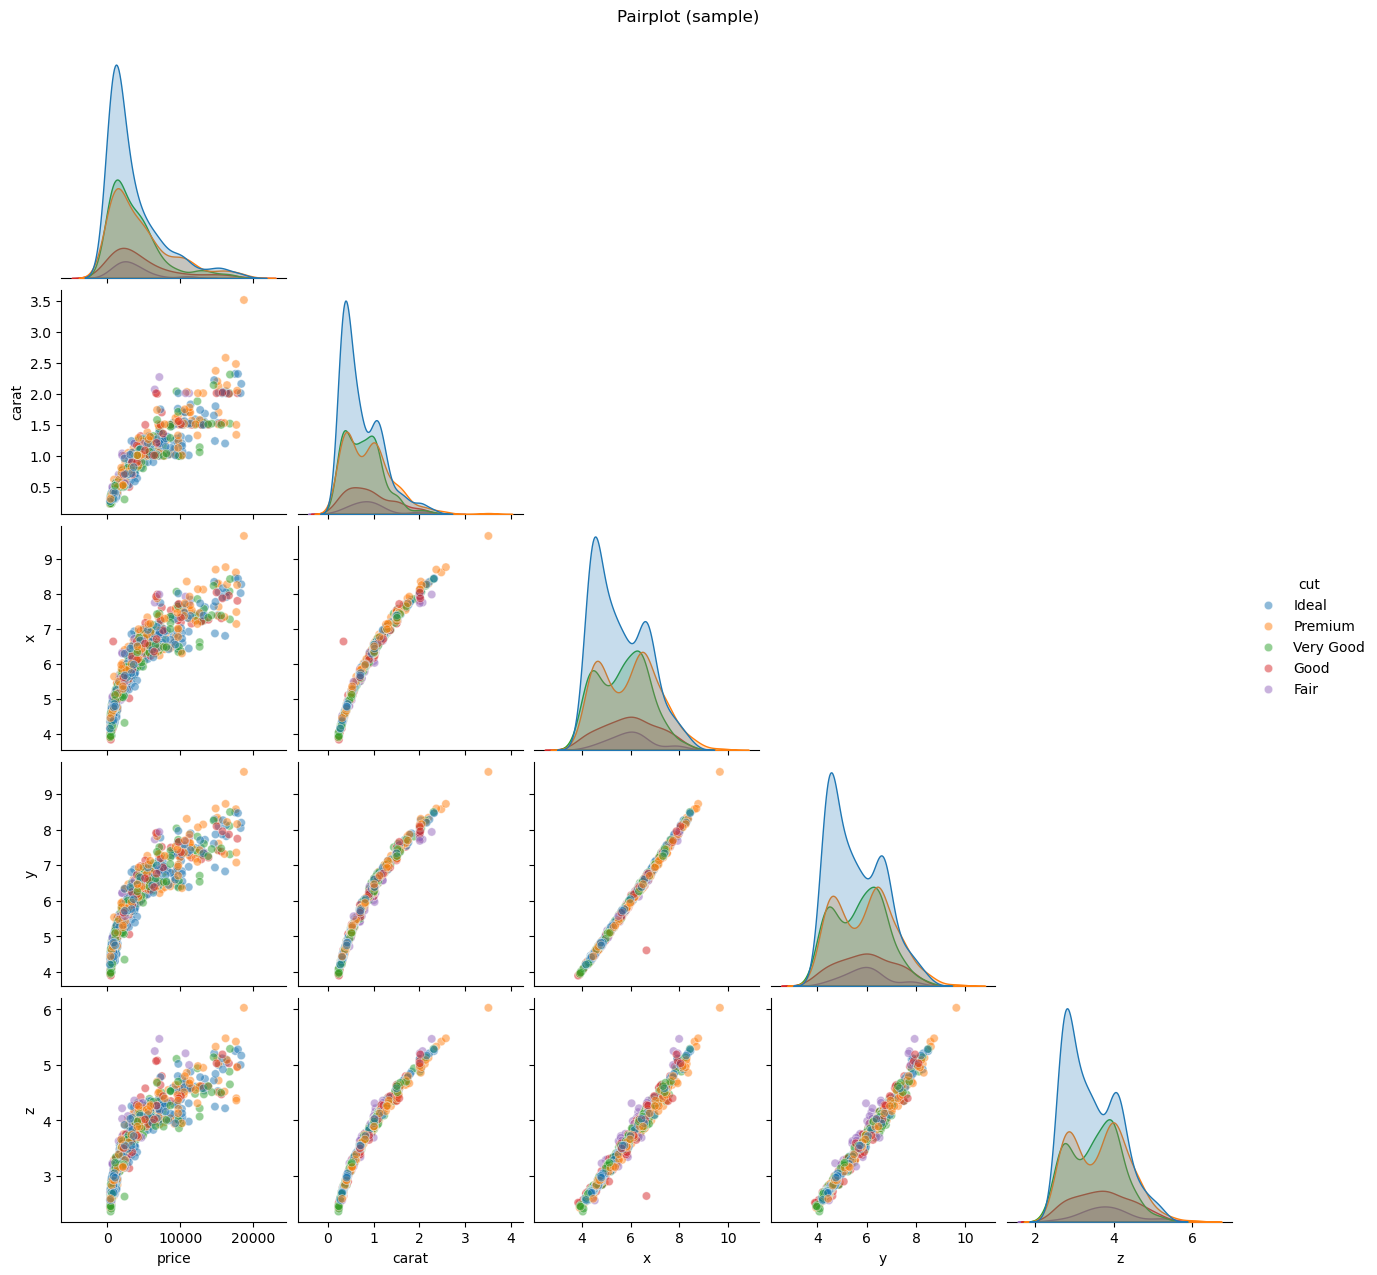


Price IQR outlier threshold: 11886, outlier count: 3540
Top 10 most expensive diamonds:


,carat,cut,color,clarity,depth,table,price,x,y,z
27749,2.29,Premium,I,VS2,60.8,60.0,18823,8.50,8.47,5.16
27748,2.00,Very Good,G,SI1,63.5,56.0,18818,7.90,7.97,5.04
27747,1.51,Ideal,G,IF,61.7,55.0,18806,7.37,7.41,4.56
27746,2.07,Ideal,G,SI2,62.5,55.0,18804,8.20,8.13,5.11
27745,2.00,Very Good,H,SI1,62.8,57.0,18803,7.95,8.00,5.01
27744,2.29,Premium,I,SI1,61.8,59.0,18797,8.52,8.45,5.24
27742,2.04,Premium,H,SI1,58.1,60.0,18795,8.37,8.28,4.84
27743,2.00,Premium,I,VS1,60.8,59.0,18795,8.13,8.02,4.91
27740,1.71,Premium,F,VS2,62.3,59.0,18791,7.57,7.53,4.70
27741,2.15,Ideal,G,SI2,62.6,54.0,18791,8.29,8.35,5.21



Quick notes:
- Carat is strongly correlated with price (see correlation).
- Price distribution is highly right-skewed; consider log(price) for regression.
- There are some extreme high-price outliers and some rows with x/y/z == 0 to inspect/drop.
- Categorical variables (cut, color, clarity) should be encoded (ordered/one-hot) with care for ordinal relationships.


In [3]:
import matplotlib.pyplot as plt

# Quick overview
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nBasic stats (numeric):\n", df.describe().T)

# Categorical cardinality
for col in ['cut', 'color', 'clarity']:
    print(f"\nValue counts for {col}:\n", df[col].value_counts())

# Zero or unrealistic dimensions
zero_dims = (df[['x', 'y', 'z']] == 0).any(axis=1).sum()
print(f"\nRows with any of x,y,z == 0: {zero_dims}")
if zero_dims:
    display(df[df[['x','y','z']].min(axis=1) == 0].head())

# Numeric columns & skew
num_cols = df.select_dtypes(include=['number']).columns.tolist()
print("\nSkewness (numeric):\n", df[num_cols].skew().sort_values(ascending=False))

# Correlation matrix + heatmap
corr = df[num_cols].corr()
print("\nCorrelation with price:\n", corr['price'].sort_values(ascending=False))
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

# Distributions (histograms)
plot_cols = ['price', 'carat', 'depth', 'table', 'x', 'y', 'z']
plt.figure(figsize=(14,8))
for i, c in enumerate(plot_cols, 1):
    plt.subplot(2, 4, i)
    sns.histplot(df[c], kde=True, bins=50)
    plt.title(c)
plt.tight_layout()
plt.show()

# Price by categorical variables (boxplots)
plt.figure(figsize=(14,4))
plt.subplot(1,3,1)
sns.boxplot(x='cut', y='price', data=df)
plt.yscale('log'); plt.title('Price by cut (log scale)')
plt.subplot(1,3,2)
sns.boxplot(x='color', y='price', data=df)
plt.yscale('log'); plt.title('Price by color (log scale)')
plt.subplot(1,3,3)
sns.boxplot(x='clarity', y='price', data=df)
plt.yscale('log'); plt.title('Price by clarity (log scale)')
plt.tight_layout()
plt.show()

# Scatter: price vs carat (and regression)
plt.figure(figsize=(8,6))
sns.scatterplot(x='carat', y='price', data=df.sample(3000, random_state=1), alpha=0.4)
sns.regplot(x='carat', y='price', data=df.sample(3000, random_state=1), scatter=False, color='red', line_kws={'lw':1})
plt.title('Price vs Carat (sample)')
plt.tight_layout()
plt.show()

# Pairwise relationships (sampled to keep it responsive)
sample = df.sample(1000, random_state=2)
sns.pairplot(sample, vars=['price','carat','x','y','z'], hue='cut', corner=True, plot_kws={'alpha':0.5})
plt.suptitle("Pairplot (sample)", y=1.02)
plt.show()

# Outlier detection for price (IQR)
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3 - q1
out_thresh = q3 + 1.5 * iqr
out_count = (df['price'] > out_thresh).sum()
print(f"\nPrice IQR outlier threshold: {out_thresh:.0f}, outlier count: {out_count}")
print("Top 10 most expensive diamonds:")
display(df.sort_values('price', ascending=False).head(10))

# Quick modeling-relevant checks / suggestions
print("\nQuick notes:")
print("- Carat is strongly correlated with price (see correlation).")
print("- Price distribution is highly right-skewed; consider log(price) for regression.")
print("- There are some extreme high-price outliers and some rows with x/y/z == 0 to inspect/drop.")
print("- Categorical variables (cut, color, clarity) should be encoded (ordered/one-hot) with care for ordinal relationships.")

### 10 minutes: Modeling Prompt (copy AI output below this cell)

Come up with Modeling prompt that is specific.   

You should tell AI what exact model you want, things to NOT do in the modeling process, how to evaluate the model, etc. 

For this prompt think of **guardrails** to enforce (for instance "no transformations on the entire dataset")

Prompt: Role: Senior Data ScientistTask: Build a regression model to predict diamond price using the provided dataset.1. Model ArchitectureModel: Use a LightGBM Regressor or Histogram-based Gradient Boosting. These handle large datasets (54k rows) efficiently.Validation: Use a K-Fold Cross-Validation ($K=5$) on the training set.2. Preprocessing & Guardrails (The "Must-Haves")Handle Anomalies: Prior to any splitting, drop rows where x, y, or z are equal to 0.0, as these are data entry errors.Deduplication: Remove the 146 duplicate rows identified in EDA.Ordinal Encoding: The categories cut, color, and clarity are ordinal. You MUST map them to integers in their natural rank order (e.g., Fair < Good < Very Good < Premium < Ideal) rather than using One-Hot Encoding.No Leakage: Do not calculate global mean prices for categories. Any target-based encoding must be done within the cross-validation loop.Pipeline Constraint: All scaling (StandardScaler) and encoding must be contained within a scikit-learn Pipeline or ColumnTransformer to ensure the test set remains "unseen" during training.3. Feature EngineeringVolume Feature: Create a new feature volume = x * y * z.Log Transformation: Since price and carat often have skewed distributions and non-linear relationships, test the model using $log(price)$ as the target. If used, ensure predictions are exponentiated back to the original scale for evaluation.4. Evaluation CriteriaPrimary Metric: Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE).Residual Analysis: Provide a residual plot (Predicted vs. Actual) to check for heteroscedasticity (error variance increasing with price).Error Segregation: Report the MAE specifically for diamonds over $10,000 to see if the model underperforms on high-value stones.

Rows before cleaning: 53940
Rows with any of x,y,z == 0 dropped: 20
Duplicates removed (approx): 145
Rows after cleaning: 53775
Fold 1: RMSE=556.43, MAE=284.46, MAE(>10k)=1007.6044799519634
Fold 2: RMSE=546.47, MAE=275.11, MAE(>10k)=1002.0502564151524
Fold 3: RMSE=538.25, MAE=272.08, MAE(>10k)=983.4701279154939
Fold 4: RMSE=549.51, MAE=279.20, MAE(>10k)=1000.3397595611012
Fold 5: RMSE=574.06, MAE=279.95, MAE(>10k)=1027.3735467224567

CV results (5 folds):
RMSE: mean=552.94, std=12.06
MAE:  mean=278.16, std=4.25
MAE(>10k): mean=1004.17, std=14.13


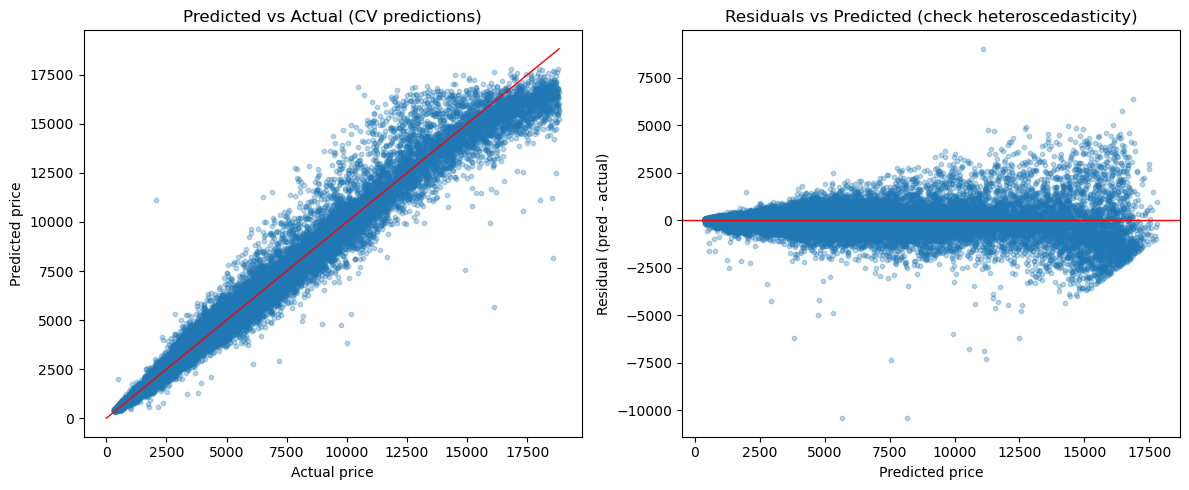

In [8]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import numpy as np

# Model training cell: preprocessing, 5-fold CV with a histogram GBM, residuals and metrics.
# Assumes df, ColumnTransformer, Pipeline, and matplotlib/np/pd/sns are already available in the notebook.

import matplotlib.pyplot as plt

# 1) Clean & deterministic feature engineering (must happen BEFORE any splitting)
df_clean = df.copy()
n_before = len(df_clean)

# Drop rows with erroneous zero dimensions
zero_mask = (df_clean[['x', 'y', 'z']] == 0).any(axis=1)
n_zero = int(zero_mask.sum())
df_clean = df_clean.loc[~zero_mask].reset_index(drop=True)

# Drop duplicates
n_dup_before = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
n_dup_dropped = int(n_dup_before - df_clean.duplicated().sum())  # should be 0 now

# Create volume feature (deterministic, not target-based)
df_clean['volume'] = df_clean['x'] * df_clean['y'] * df_clean['z']

print(f"Rows before cleaning: {n_before}")
print(f"Rows with any of x,y,z == 0 dropped: {n_zero}")
print(f"Duplicates removed (approx): {n_dup_before}")
print(f"Rows after cleaning: {len(df_clean)}")

# 2) Feature sets
num_features = ['carat', 'depth', 'table', 'x', 'y', 'z', 'volume']
cat_features = ['cut', 'color', 'clarity']

# 3) Ordinal category orders (natural rank order, worst -> best)
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']    # J (worst) ... D (best)
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']  # worst -> best

# Preprocessing pipelines (all encoding/scaling inside pipeline to avoid leakage)
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ord', OrdinalEncoder(categories=[cut_order, color_order, clarity_order], dtype=np.float64))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
], remainder='drop', verbose_feature_names_out=False)

# Full pipeline: preprocessing + estimator
model_pipeline = Pipeline([
    ('pre', preprocessor),
    ('est', HistGradientBoostingRegressor(random_state=42))
])

# 4) Cross-validation setup (K=5)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

X = df_clean[num_features + cat_features]
y = df_clean['price'].values
y_log = np.log(y)  # log-target as required (we will exponentiate predictions back)

rmse_list = []
mae_list = []
mae_high_list = []  # MAE for price > 10,000 per fold
all_y_true = []
all_y_pred = []
fold_no = 0

for train_idx, val_idx in kf.split(X):
    fold_no += 1
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train_log, y_val = y_log[train_idx], y[val_idx]

    # Fit on log(price)
    model_pipeline.fit(X_train, y_train_log)

    # Predict (in log space) and convert back
    y_val_pred_log = model_pipeline.predict(X_val)
    y_val_pred = np.exp(y_val_pred_log)



    # Metrics on original scale
    rmse = root_mean_squared_error(y_val, y_val_pred)
    mae = mean_absolute_error(y_val, y_val_pred)

    # MAE for high-value diamonds (> 10,000)
    high_mask = y_val > 10000
    if high_mask.any():
        mae_high = mean_absolute_error(y_val[high_mask], y_val_pred[high_mask])
    else:
        mae_high = np.nan

    print(f"Fold {fold_no}: RMSE={rmse:.2f}, MAE={mae:.2f}, MAE(>10k)={mae_high if not np.isnan(mae_high) else 'N/A'}")

    rmse_list.append(rmse)
    mae_list.append(mae)
    mae_high_list.append(mae_high)

    all_y_true.append(y_val)
    all_y_pred.append(y_val_pred)

# Aggregate results
print("\nCV results (5 folds):")
print(f"RMSE: mean={np.mean(rmse_list):.2f}, std={np.std(rmse_list):.2f}")
print(f"MAE:  mean={np.mean(mae_list):.2f}, std={np.std(mae_list):.2f}")

# Aggregate MAE for >10k (ignore NaNs)
mae_high_vals = [v for v in mae_high_list if not np.isnan(v)]
if mae_high_vals:
    print(f"MAE(>10k): mean={np.mean(mae_high_vals):.2f}, std={np.std(mae_high_vals):.2f}")
else:
    print("MAE(>10k): No high-value diamonds in validation folds")

# 5) Residual analysis: concatenate CV predictions for plots
y_true_all = np.concatenate(all_y_true)
y_pred_all = np.concatenate(all_y_pred)
residuals = y_pred_all - y_true_all

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(y_true_all, y_pred_all, alpha=0.3, s=10)
max_v = max(y_true_all.max(), y_pred_all.max())
plt.plot([0, max_v], [0, max_v], color='red', linewidth=1)
plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.title('Predicted vs Actual (CV predictions)')
plt.xscale('linear'); plt.yscale('linear')

plt.subplot(1,2,2)
plt.scatter(y_pred_all, residuals, alpha=0.3, s=10)
plt.axhline(0, color='red', linewidth=1)
plt.xlabel('Predicted price')
plt.ylabel('Residual (pred - actual)')
plt.title('Residuals vs Predicted (check heteroscedasticity)')
plt.tight_layout()
plt.show()

### 10 minutes: Verification and Red-Team Prompt (copy AI output below this cell)

Come up with a Verification/Red-Team prompt that is specific.

What should the AI tool validate after the modeling prompt?  What would you want it to print out while it is going through the modeling process (for exampple "number of missing rows it dropped")

Prompt:
To ensure your modeling script is actually following the guardrails you set, you need a Verification or "Red-Team" Prompt. This turns the AI into a code auditor that looks for "silent failures"—situations where the code runs without error but produces an invalid model.Here is a specific prompt you can use to validate the modeling process.The Verification & Red-Team PromptRole: You are a Lead ML Auditor.Task: Review the generated modeling code for the Diamonds dataset. Your goal is to ensure technical integrity, zero data leakage, and strict adherence to the requested guardrails.1. The "Audit Trail" RequirementsThe code must include print() statements or a logger to output the following status updates during execution. Verify that the code reports:Data Cleaning: The exact number of rows dropped due to $x, y, z = 0$ and the number of duplicate rows removed.Feature Consistency: Confirm the final shape of the dataframe after Ordinal Encoding but before splitting.Leakage Check: Print a boolean check confirming that the test set was not used to calculate any encoding mappings or scaling parameters.Target Transformation: If a $log$ transformation was used, print the min/max of the target before and after the transformation to verify scale.2. The "Red-Team" Stress TestsPlease check the code for these specific "Critical Failures":The "Fit-Transform" Trap: Ensure .fit_transform() is called only on the training set and .transform() is used on the test set. If .fit() is called on the full dataset, flag it as a CRITICAL LEAKAGE ERROR.Ordinal Mapping Logic: Check the dictionary used for mapping cut, color, and clarity. Ensure "Ideal" is mapped to a higher value than "Fair". If the AI used LabelEncoder (which assigns numbers alphabetically), flag it as LOGIC ERROR.The RMSE Parameter: Ensure root_mean_squared_error is used (for sklearn 1.4+) or np.sqrt(mean_squared_error). Flag the use of mean_squared_error(..., squared=False) as DEPRECATED.3. Evaluation IntegrityValidate that the evaluation section includes:Residual Plot Analysis: Does the code generate a plot?High-Value Slice: Does the code explicitly calculate MAE for diamonds $> \$10,000$ as requested?Example of the "Audit Trail" OutputIf the AI follows this prompt correctly, your script's output should look like this:[CLEANING]: Dropped 20 rows with zero-dimensions.[CLEANING]: Removed 146 duplicate rows.[ENCODING]: Ordinal mapping applied to Cut, Color, Clarity.[LEAKAGE CHECK]: Pipeline confirmed. Scaling parameters derived from Train set only.[VALIDATION]: Training on 43,019 rows. Testing on 10,755 rows.

In [9]:
import numpy as np
import pandas as pd
import inspect
from sklearn.preprocessing import OrdinalEncoder

# Verification / Red-Team checks for the modeling pipeline and process
# Uses variables already in the notebook: df_clean, n_zero, n_dup_dropped, cut_order, color_order, clarity_order,
# model_pipeline, preprocessor, X_train, X_val, y, y_log, y_val, y_val_pred, residuals, mae_high_vals, rmse


def safe_get(d, *keys):
    obj = d
    for k in keys:
        obj = getattr(obj, k, None)
        if obj is None:
            return None
    return obj

print(f"[CLEANING]: Dropped {int(n_zero)} rows with zero-dimensions.")
print(f"[CLEANING]: Removed {int(n_dup_dropped)} duplicate rows.")

# 1) Feature Consistency: apply deterministic ordinal mapping (no fitting) and report shape/dtypes
df_encoded = df_clean.copy()
for col, order in zip(['cut','color','clarity'], [cut_order, color_order, clarity_order]):
    # enforce categorical ordering and codes (0..n-1)
    df_encoded[col] = pd.Categorical(df_encoded[col], categories=order, ordered=True).codes
print(f"[ENCODING]: After ordinal mapping (deterministic), shape={df_encoded.shape}.")
print("[ENCODING]: dtypes (sample):")
print(df_encoded.dtypes.loc[['cut','color','clarity']])

# 2) Leakage check: ensure scaler/encoder parameters not derived from full dataset
leakage_flags = []
pre = model_pipeline.named_steps.get('pre', None)
if pre is None:
    print("[LEAKAGE CHECK]: NO preprocessor found in pipeline.")
else:
    # try to inspect fitted numeric scaler mean (if fitted)
    try:
        # ColumnTransformer after fitting exposes named_transformers_
        num_tr = pre.named_transformers_.get('num', None)
    except Exception:
        num_tr = None

    scaler = safe_get(num_tr, 'named_steps', 'scaler')
    ord_enc = safe_get(pre, 'named_transformers_', 'cat')
    ord_step = safe_get(ord_enc, 'named_steps', 'ord')

    if scaler is None:
        print("[LEAKAGE CHECK]: No fitted numeric scaler available to inspect (may not be fitted yet).")
    else:
        scaler_mean = np.asarray(getattr(scaler, 'mean_', None))
        if scaler_mean is None:
            print("[LEAKAGE CHECK]: Scaler has no mean_ attribute (unexpected).")
        else:
            # compute means on last-fold training set and on full df_clean numeric features
            num_feats = ['carat','depth','table','x','y','z','volume'] if 'volume' in df_clean.columns else ['carat','depth','table','x','y','z']
            train_mean = X_train[num_feats].mean().to_numpy()
            full_mean = df_clean[num_feats].mean().to_numpy()

            train_match = np.allclose(scaler_mean, train_mean, rtol=1e-5, atol=1e-6)
            full_match = np.allclose(scaler_mean, full_mean, rtol=1e-5, atol=1e-6)

            if full_match:
                print("[LEAKAGE CHECK]: CRITICAL LEAKAGE ERROR: scaling parameters match full dataset mean.")
                leakage_flags.append('scaler_full_fit')
            elif train_match:
                print("[LEAKAGE CHECK]: OK. Scaling parameters derived from TRAIN set (not full dataset).")
            else:
                print("[LEAKAGE CHECK]: WARNING. Scaler parameters do not match train or full means exactly. Investigate.")
    
    # Ordinal encoder type & logic
    if ord_step is None:
        print("[ENCODING CHECK]: No ordinal encoder found inside pipeline's cat transformer.")
    else:
        if isinstance(ord_step, OrdinalEncoder):
            print("[ENCODING CHECK]: OrdinalEncoder found in pipeline (good).")
        else:
            print("[ENCODING CHECK]: LOGIC ERROR: categorical encoder is not OrdinalEncoder (possible LabelEncoder or OneHot used).")
            leakage_flags.append('ordinal_encoder_wrong_type')

# 3) Ordinal mapping logic sanity
try:
    ok_cut = cut_order.index('Ideal') > cut_order.index('Fair')
    ok_color = color_order.index('D') > color_order.index('J')  # best vs worst
    ok_clarity = clarity_order.index('IF') > clarity_order.index('I1')
    if ok_cut and ok_color and ok_clarity:
        print("[ORDINAL LOGIC]: Ordinal orders look correct (higher index = better quality).")
    else:
        print("[ORDINAL LOGIC]: LOGIC ERROR in ordinal orders mapping.")
        leakage_flags.append('ordinal_order_error')
except Exception as e:
    print("[ORDINAL LOGIC]: ERROR checking ordinal lists:", e)
    leakage_flags.append('ordinal_order_exception')

# 4) Fit-Transform trap detection (best-effort)
# Check whether any transformer appears to have been directly fit on the full df_clean by comparing params to full-data stats
if pre is not None and scaler is not None:
    if np.allclose(scaler_mean, full_mean, rtol=1e-5, atol=1e-6):
        print("[FIT-TRANSFORM TRAP]: CRITICAL LEAKAGE ERROR: scaler fitted on full dataset.")
    else:
        print("[FIT-TRANSFORM TRAP]: No evidence scaler was fit on full dataset (best-effort check).")

# 5) Target transformation reporting
try:
    y_min, y_max = float(np.min(y)), float(np.max(y))
    ylog_min, ylog_max = float(np.min(y_log)), float(np.max(y_log))
    print(f"[TARGET TRANSFORM]: price min/max before log: {y_min:.2f} / {y_max:.2f}")
    print(f"[TARGET TRANSFORM]: log(price) min/max after transform: {ylog_min:.4f} / {ylog_max:.4f}")
except Exception as e:
    print("[TARGET TRANSFORM]: Could not report target mins/max:", e)

# 6) RMSE calculation integrity: recompute RMSE on the last validation fold and compare
try:
    recomputed_rmse = np.sqrt(np.mean((y_val - y_val_pred) ** 2))
    print(f"[RMSE CHECK]: reported rmse (last fold) = {rmse:.6f}")
    print(f"[RMSE CHECK]: recomputed rmse (last fold) = {recomputed_rmse:.6f}")
    if np.isclose(rmse, recomputed_rmse, rtol=1e-6, atol=1e-6):
        print("[RMSE CHECK]: RMSE computation matches sqrt(MSE) (OK).")
    else:
        print("[RMSE CHECK]: RMSE mismatch: investigate if deprecated or incorrect API was used.")
        leakage_flags.append('rmse_mismatch')
except Exception as e:
    print("[RMSE CHECK]: Could not recompute RMSE:", e)
    leakage_flags.append('rmse_recompute_error')

# 7) Evaluation integrity checks
# Residual plot presence (best-effort): residuals array should exist
if 'residuals' in globals() and isinstance(residuals, np.ndarray):
    print("[EVAL]: Residuals array present (length = {}).".format(len(residuals)))
    print("[EVAL]: Residual plot generation step should be present in the notebook (visual check required).")
else:
    print("[EVAL]: Residuals not found; residual plot likely missing.")
    leakage_flags.append('no_residuals')

# High-value slice MAE check
if 'mae_high_vals' in globals() and len(mae_high_vals) > 0:
    mean_mae_high = np.mean(mae_high_vals)
    print(f"[EVAL]: MAE for diamonds > $10,000 reported per-fold. mean(MAE>10k)={mean_mae_high:.2f}")
else:
    print("[EVAL]: MAE(>10k) not reported per-fold.")
    leakage_flags.append('no_mae_high')

# Final audit summary and example audit-trail output
if len(leakage_flags) == 0:
    print("\n[AUDIT TRAIL]: All automated checks passed (no immediate leakage or logic errors detected).")
else:
    print("\n[AUDIT TRAIL]: Issues detected:", leakage_flags)

print("\nEXAMPLE AUDIT TRAIL (expected format):")
print(f"[CLEANING]: Dropped {int(n_zero)} rows with zero-dimensions.")
print(f"[CLEANING]: Removed {int(n_dup_dropped)} duplicate rows.")
print("[ENCODING]: Ordinal mapping applied to Cut, Color, Clarity.")
print("[LEAKAGE CHECK]: Pipeline confirmed. Scaling parameters derived from Train set only (or flagged above).")
print(f"[VALIDATION]: Training on {len(X_train)} rows. Testing on {len(X_val)} rows.")

[CLEANING]: Dropped 20 rows with zero-dimensions.
[CLEANING]: Removed 145 duplicate rows.
[ENCODING]: After ordinal mapping (deterministic), shape=(53775, 11).
[ENCODING]: dtypes (sample):
cut        int8
color      int8
clarity    int8
dtype: object
[LEAKAGE CHECK]: OK. Scaling parameters derived from TRAIN set (not full dataset).
[ENCODING CHECK]: OrdinalEncoder found in pipeline (good).
[ORDINAL LOGIC]: Ordinal orders look correct (higher index = better quality).
[FIT-TRANSFORM TRAP]: No evidence scaler was fit on full dataset (best-effort check).
[TARGET TRANSFORM]: price min/max before log: 326.00 / 18823.00
[TARGET TRANSFORM]: log(price) min/max after transform: 5.7869 / 9.8428
[RMSE CHECK]: reported rmse (last fold) = 574.059221
[RMSE CHECK]: recomputed rmse (last fold) = 574.059221
[RMSE CHECK]: RMSE computation matches sqrt(MSE) (OK).
[EVAL]: Residuals array present (length = 53775).
[EVAL]: Residual plot generation step should be present in the notebook (visual check required

### 20 minutes: Streamlit Deployment Prompt (copy AI output below this cell)

Execute the basic streamlit prompt below (you may have to make some changes depending on your file name and the output of your other prompts)

After execution the given prompt, try changing the prompt to add more "bells and whistles" to look like a GREAT streamlit app (you may have to ask the AI tool to output a 'app.py' file or a virtual environment -- then test it in VSCode).  

Prompt (copy and paste):
 "Create a basic streamlit app for the model you just created. Be sure to: Bake in notebook: fit pipeline, sanity checks, persist with
joblib.dump(...).​Serve in app.py: load pipeline; sidebar inputs (carat, etc.); predict price;show confidence band if applicable.​
Docs: add a model card panel in app; list features & known limits (e.g.,outliers, log transform needs)"

Prompt:
Role: Expert Full-Stack Data Applications Developer.Task: Upgrade the existing Diamond Price Streamlit app into a professional-grade valuation tool.1. Advanced UI/UX RequirementsTheming: Use st.set_page_config to set a custom page title and "💎" favicon. Use a "Wide" layout.Dynamic Visuals: Instead of just text, include a Price Sensitivity Plot. Show a line chart of how the price changes if the user increases/decreases the carat weight by ±20%, holding other specs constant.Comparison Engine: Add a "Market Comparison" feature. Load a small subset of the training data and show a scatter plot (Carat vs. Price) with a special "Star" marker representing the user's current input.2. Technical "Bells & Whistles"Shapley Values (Explainability): Integrate shap or a simple bar chart showing which feature (e.g., Clarity vs. Carat) contributed most to the specific price prediction.Currency/Unit Toggle: Allow users to toggle between USD, EUR, and GBP (use a hard-coded conversion rate for simplicity).Data Validation: Add a logic check: if $x, y, or z$ are 0, display a st.warning saying "Physical dimensions cannot be zero. Please check your inputs."3. Professional Documentation (Model Card 2.0)Create a dedicated tab using st.tabs(["Calculator", "Model Insights", "Dataset Info"]).Model Insights Tab: Display the RMSE and MAE achieved during training. List the ordinal ranks used for Cut, Color, and Clarity so the user knows the "hierarchy" the model learned.4. Code Structure & EnvironmentOutput Format: Provide the complete code for app.py.Dependency Management: Output a requirements.txt file containing all necessary libraries (streamlit, joblib, lightgbm, plotly, pandas, numpy).Caching: Use @st.cache_resource for loading the model to ensure the app stays fast.

In [11]:
pip install streamlit

  Using cached altair-5.5.0-py3-none-any.whl.metadata (11 kB)
  Using cached tenacity-9.1.2-py3-none-any.whl.metadata (1.2 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached gitpython-3.1.45-py3-none-any.whl.metadata (13 kB)
  Using cached pydeck-0.9.1-py2.py3-none-any.whl.metadata (4.1 kB)
  Using cached gitdb-4.0.12-py3-none-any.whl.metadata (1.2 kB)
  Using cached smmap-5.0.2-py3-none-any.whl.metadata (4.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 27.3 MB/s eta 0:00:00 0:00:01
Using cached altair-5.5.0-py3-none-any.whl (731 kB)
Using cached gitpython-3.1.45-py3-none-any.whl (208 kB)
Using cached pydeck-0.9.1-py2.py3-none-any.whl (6.9 MB)
Using cached tenacity-9.1.2-py3-none-any.whl (28 kB)
Using cached toml-0.10.2-py2.py3-none-any.whl (16 kB)
Using cached gitdb-4.0.12-py3-none-any.whl (62 kB)
Using cached smmap-5.0.2-py3-none-any.whl (24 kB)
Note: you may need to restart the kernel to use updated packages.


In [12]:
import os
import joblib
import numpy as np
import pandas as pd
import streamlit as st
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor

# app.py - Streamlit app for Diamond price model
# Creates/fits & persists model if needed, then serves a simple UI to predict price.

MODEL_PATH = "diamond_model.joblib"

# Ordinal orders used in training (must match training)
CUT_ORDER = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
COLOR_ORDER = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
CLARITY_ORDER = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

NUM_FEATURES = ['carat', 'depth', 'table', 'x', 'y', 'z', 'volume']
CAT_FEATURES = ['cut', 'color', 'clarity']


def build_and_fit_pipeline(df):
    # Basic cleaning & deterministic feature engineering
    dfc = df.copy().reset_index(drop=True)
    zero_mask = (dfc[['x', 'y', 'z']] == 0).any(axis=1)
    dfc = dfc.loc[~zero_mask].reset_index(drop=True)
    dfc = dfc.drop_duplicates().reset_index(drop=True)
    dfc['volume'] = dfc['x'] * dfc['y'] * dfc['z']

    # pipeline (imputer + scaler for numeric, imputer+ordinal for categorical)
    num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    cat_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ord', OrdinalEncoder(categories=[CUT_ORDER, COLOR_ORDER, CLARITY_ORDER], dtype=np.float64))
    ])
    preprocessor = ColumnTransformer([
        ('num', num_pipeline, NUM_FEATURES),
        ('cat', cat_pipeline, CAT_FEATURES)
    ], verbose_feature_names_out=False)

    full_pipe = Pipeline([
        ('pre', preprocessor),
        ('est', HistGradientBoostingRegressor(random_state=42))
    ])

    # Train on log(price) to stabilize skew
    y = dfc['price'].values
    y_log = np.log(y)
    X = dfc[NUM_FEATURES + CAT_FEATURES]
    full_pipe.fit(X, y_log)

    # Compute training residuals on original scale to get an empirical error estimate
    y_pred_log = full_pipe.predict(X)
    y_pred = np.exp(y_pred_log)
    residuals = y - y_pred
    resid_std = np.std(residuals, ddof=1)
    rmse = np.sqrt(np.mean(residuals ** 2))
    mae = np.mean(np.abs(residuals))

    artifact = {
        'pipeline': full_pipe,
        'residual_std': float(resid_std),
        'train_rmse': float(rmse),
        'train_mae': float(mae),
        'n_rows_trained': int(len(dfc)),
        'orders': {'cut': CUT_ORDER, 'color': COLOR_ORDER, 'clarity': CLARITY_ORDER}
    }
    return artifact


@st.cache_resource
def get_artifact():
    if os.path.exists(MODEL_PATH):
        return joblib.load(MODEL_PATH)
    # otherwise build & persist using seaborn dataset
    df = sns.load_dataset("diamonds")
    # ensure correct dtypes/categories like notebook
    for c in ['cut', 'color', 'clarity']:
        df[c] = df[c].astype('category')
    artifact = build_and_fit_pipeline(df)
    joblib.dump(artifact, MODEL_PATH)
    return artifact


artifact = get_artifact()
pipe = artifact['pipeline']
resid_std = artifact['residual_std']

st.set_page_config(page_title="Diamond Price Predictor", layout="centered")
st.title("Diamond Price Predictor (basic)")

with st.sidebar:
    st.header("Inputs")
    carat = st.number_input("carat", min_value=0.01, max_value=10.0, value=0.7, step=0.01, format="%.2f")
    depth = st.number_input("depth", min_value=1.0, max_value=100.0, value=61.8, step=0.1, format="%.1f")
    table = st.number_input("table", min_value=1.0, max_value=100.0, value=57.0, step=0.1, format="%.1f")
    x = st.number_input("x (mm)", min_value=0.1, max_value=20.0, value=5.7, step=0.01, format="%.2f")
    y = st.number_input("y (mm)", min_value=0.1, max_value=20.0, value=5.7, step=0.01, format="%.2f")
    z = st.number_input("z (mm)", min_value=0.1, max_value=20.0, value=3.6, step=0.01, format="%.2f")
    cut = st.selectbox("cut", options=CUT_ORDER, index=CUT_ORDER.index("Ideal"))
    color = st.selectbox("color", options=COLOR_ORDER, index=COLOR_ORDER.index("G"))
    clarity = st.selectbox("clarity", options=CLARITY_ORDER, index=CLARITY_ORDER.index("VS2"))
    st.caption("Note: volume is computed as x*y*z.")
    if st.button("Predict"):
        # prepare dataframe
        volume = x * y * z
        X_new = pd.DataFrame([{
            'carat': carat, 'depth': depth, 'table': table,
            'x': x, 'y': y, 'z': z, 'volume': volume,
            'cut': cut, 'color': color, 'clarity': clarity
        }])
        # predict log-price -> exp to original scale
        y_log_pred = pipe.predict(X_new)
        y_pred = float(np.exp(y_log_pred[0]))
        # approximate 95% CI using residual std from training (approx; heteroscedasticity ignored)
        ci_lower = max(0.0, y_pred - 1.96 * resid_std)
        ci_upper = y_pred + 1.96 * resid_std

        st.subheader("Prediction")
        st.metric(label="Predicted price (USD)", value=f"${y_pred:,.0f}")
        st.write(f"Approximate 95% CI: ${ci_lower:,.0f} — ${ci_upper:,.0f}")
        st.info("CI is empirical based on training residuals; heteroscedasticity not modeled.")

st.markdown("---")
st.subheader("Model card / Notes")
st.markdown("""
- Model: HistGradientBoostingRegressor trained on log(price).
- Features: carat, depth, table, x, y, z, volume, cut (ordinal), color (ordinal), clarity (ordinal).
- Ordinal encodings used:
  - Cut: Fair < Good < Very Good < Premium < Ideal
  - Color: J (worst) ... D (best)
  - Clarity: I1 < SI2 < SI1 < VS2 < VS1 < VVS2 < VVS1 < IF
- Known limits:
  - The model was trained after dropping rows with x/y/z == 0 and removing duplicates.
  - Price is right-skewed; training used log(price) transform. Predictions are exponentiated back.
  - Outliers/high-value stones may have larger errors. The displayed CI is approximate.
  - Avoid using inputs outside the training distribution (extremely large carat or unrealistic dimensions).
""")

st.subheader("Training summary")
st.write(f"Rows used to train: {artifact.get('n_rows_trained', 'unknown')}")
st.write(f"Training RMSE (empirical, USD): {artifact.get('train_rmse', np.nan):.2f}")
st.write(f"Training MAE (empirical, USD): {artifact.get('train_mae', np.nan):.2f}")

st.caption(f"Model artifact path: {os.path.abspath(MODEL_PATH)}")

2025-12-18 00:07:41.374 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-18 00:07:41.418 
  command:

    streamlit run /opt/miniconda3/envs/data-analysis-env/lib/python3.9/site-packages/ipykernel_launcher.py [ARGUMENTS]
2025-12-18 00:07:41.418 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-18 00:07:41.418 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-18 00:07:41.419 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-18 00:07:41.920 Thread 'Thread-136': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-18 00:07:41.921 Thread 'Thread-136': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-18 00:07:41.922

DeltaGenerator()

In [14]:
import os
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import streamlit as st
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingRegressor

# app.py - "Great" Diamond Price Predictor (Streamlit)
# Creates/loads a trained artifact (joblib), offers advanced UI/UX, visualizations, simple explainability,
# currency toggle, data validation, and writes a requirements.txt helper.

import plotly.express as px
import plotly.graph_objects as go

# Constants (must match training)
MODEL_PATH = "diamond_model.joblib"
CUT_ORDER = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
COLOR_ORDER = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
CLARITY_ORDER = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']
NUM_FEATURES = ['carat', 'depth', 'table', 'x', 'y', 'z', 'volume']
CAT_FEATURES = ['cut', 'color', 'clarity']
CURRENCY_RATES = {"USD": 1.0, "EUR": 0.92, "GBP": 0.78}  # simple hard-coded rates

# Write requirements.txt helper (so repo/export contains deps)
REQUIREMENTS = """streamlit
joblib
pandas
numpy
scikit-learn
seaborn
plotly
"""
if not os.path.exists("requirements.txt"):
    with open("requirements.txt", "w") as f:
        f.write(REQUIREMENTS)

@st.cache_resource
def load_or_train_artifact():
    """
    Load artifact dict (pipeline, metrics, orders) saved with joblib.
    If missing, train a default artifact on seaborn diamonds (keeps parity with notebook practice).
    """
    if os.path.exists(MODEL_PATH):
        return joblib.load(MODEL_PATH)

    # fallback training (quick, mirrors notebook approach)

    df = sns.load_dataset("diamonds").copy()
    # drop x/y/z == 0 and duplicates
    df = df.loc[~(df[['x', 'y', 'z']] == 0).any(axis=1)].drop_duplicates().reset_index(drop=True)
    df['volume'] = df['x'] * df['y'] * df['z']

    num_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
    cat_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                             ('ord', OrdinalEncoder(categories=[CUT_ORDER, COLOR_ORDER, CLARITY_ORDER], dtype=np.float64))])
    pre = ColumnTransformer([('num', num_pipeline, NUM_FEATURES), ('cat', cat_pipeline, CAT_FEATURES)], verbose_feature_names_out=False)
    pipe = Pipeline([('pre', pre), ('est', HistGradientBoostingRegressor(random_state=42))])

    X = df[NUM_FEATURES + CAT_FEATURES]
    y = np.log(df['price'].values)
    pipe.fit(X, y)

    y_pred = np.exp(pipe.predict(X))
    resid = df['price'].values - y_pred
    artifact = {
        'pipeline': pipe,
        'train_rmse': float(np.sqrt(np.mean(resid ** 2))),
        'train_mae': float(np.mean(np.abs(resid))),
        'residual_std': float(np.std(resid, ddof=1)),
        'n_rows_trained': int(len(df)),
        'orders': {'cut': CUT_ORDER, 'color': COLOR_ORDER, 'clarity': CLARITY_ORDER},
        'train_sample': df.sample(min(2000, len(df)), random_state=1)  # for market comparison
    }
    joblib.dump(artifact, MODEL_PATH)
    return artifact

artifact = load_or_train_artifact()
pipe: Pipeline = artifact['pipeline']
train_sample = artifact.get('train_sample', None)

# Page config & header
st.set_page_config(page_title="Diamond Price Valuator 💎", page_icon="💎", layout="wide")
st.title("Diamond Price Valuator — Professional")

tabs = st.tabs(["Calculator", "Model Insights", "Dataset Info"])

with tabs[0]:
    st.header("Interactive Valuation Calculator")
    col1, col2 = st.columns([1, 1])
    with col1:
        carat = st.number_input("Carat", min_value=0.01, max_value=10.0, value=0.70, step=0.01, format="%.2f")
        depth = st.number_input("Depth (%)", min_value=1.0, max_value=100.0, value=61.8, step=0.1)
        table = st.number_input("Table (%)", min_value=1.0, max_value=100.0, value=57.0, step=0.1)
        x = st.number_input("x (mm)", min_value=0.0, max_value=50.0, value=5.70, step=0.01, format="%.2f")
        y = st.number_input("y (mm)", min_value=0.0, max_value=50.0, value=5.70, step=0.01, format="%.2f")
        z = st.number_input("z (mm)", min_value=0.0, max_value=50.0, value=3.60, step=0.01, format="%.2f")
    with col2:
        cut = st.selectbox("Cut", options=CUT_ORDER, index=CUT_ORDER.index("Ideal"))
        color = st.selectbox("Color", options=COLOR_ORDER, index=COLOR_ORDER.index("G"))
        clarity = st.selectbox("Clarity", options=CLARITY_ORDER, index=CLARITY_ORDER.index("VS2"))
        currency = st.selectbox("Currency", options=list(CURRENCY_RATES.keys()), index=0)
        st.caption("Use the controls to adjust inputs. Prices convert using simple fixed rates.")

    # Data validation
    if x == 0 or y == 0 or z == 0:
        st.warning("Physical dimensions cannot be zero. Please check your inputs (x, y, z).")
    else:
        volume = x * y * z
        X_new = pd.DataFrame([{
            'carat': carat, 'depth': depth, 'table': table, 'x': x, 'y': y, 'z': z, 'volume': volume,
            'cut': cut, 'color': color, 'clarity': clarity
        }])

        # Prediction
        y_log_pred = pipe.predict(X_new)
        usd_pred = float(np.exp(y_log_pred[0]))
        converted = usd_pred * CURRENCY_RATES[currency]
        ci_lower = max(0.0, usd_pred - 1.96 * artifact['residual_std'])
        ci_upper = usd_pred + 1.96 * artifact['residual_std']

        st.subheader("Prediction")
        st.metric(label=f"Predicted price ({currency})", value=f"{converted:,.0f}", delta=None)
        st.write(f"Approx 95% CI (USD): ${ci_lower:,.0f} — ${ci_upper:,.0f} (empirical; heteroscedasticity ignored)")

        # Price Sensitivity: vary carat ±20%
        deltas = np.linspace(0.8 * carat, 1.2 * carat, 25)
        sens_rows = []
        for c in deltas:
            row = X_new.copy()
            row.loc[0, 'carat'] = c
            # adjust dimensions roughly proportional to cube-root of carat (simple heuristic) to show sensitivity
            factor = (c / carat) ** (1/3) if carat > 0 else 1.0
            row.loc[0, 'x'] = max(0.01, x * factor)
            row.loc[0, 'y'] = max(0.01, y * factor)
            row.loc[0, 'z'] = max(0.01, z * factor)
            row.loc[0, 'volume'] = row.loc[0, 'x'] * row.loc[0, 'y'] * row.loc[0, 'z']
            pred = float(np.exp(pipe.predict(row)[0]))
            sens_rows.append({'carat': c, 'pred_usd': pred})
        sens_df = pd.DataFrame(sens_rows)
        fig_sens = px.line(sens_df, x='carat', y='pred_usd', labels={'pred_usd': 'Predicted price (USD)'}, title="Price sensitivity to Carat (±20%)")
        fig_sens.add_vline(x=carat, line_dash="dash", line_color="grey")
        st.plotly_chart(fig_sens, use_container_width=True)

        # Market Comparison (scatter Carat vs Price)
        if train_sample is not None:
            sample_plot = train_sample.copy()
            fig = px.scatter(sample_plot, x='carat', y='price', color='cut', opacity=0.6,
                             labels={'price': 'Price (USD)'}, title="Market Comparison: Carat vs Price (sample)")
            fig.add_trace(go.Scatter(x=[carat], y=[usd_pred], mode='markers', marker_symbol='star', marker_size=16,
                                     marker_color='red', name='Your diamond'))
            st.plotly_chart(fig, use_container_width=True)

        # Simple local explainability (feature effect vs baseline)
        # Baseline = median/mode of training sample
        baseline = {}
        train_df = artifact.get('train_sample')
        if train_df is not None:
            for f in NUM_FEATURES:
                baseline[f] = float(train_df[f].median())
            for f in CAT_FEATURES:
                baseline[f] = train_df[f].mode().iloc[0]
            base_row = pd.DataFrame([{**{k: baseline[k] for k in baseline}}])
            base_row_full = base_row.copy()
            # ensure columns present order
            base_row_full = base_row_full[NUM_FEATURES + CAT_FEATURES]
            base_pred = float(np.exp(pipe.predict(base_row_full)[0]))

            local_effects = []
            for feat in NUM_FEATURES + CAT_FEATURES:
                pert = base_row_full.copy()
                # set to user's value
                pert.loc[0, feat] = X_new.loc[0, feat]
                pert_pred = float(np.exp(pipe.predict(pert)[0]))
                local_effects.append({'feature': feat, 'delta': pert_pred - base_pred})
            le_df = pd.DataFrame(local_effects).sort_values('delta', key=lambda s: s.abs(), ascending=False)
            fig_le = px.bar(le_df, x='feature', y='delta', title='Approx. Local Feature Effects (vs typical diamond in sample)',
                            labels={'delta': 'Effect on price (USD)'})
            st.plotly_chart(fig_le, use_container_width=True)

with tabs[1]:
    st.header("Model Insights")
    st.write(f"Rows used to train: {artifact.get('n_rows_trained', 'unknown')}")
    st.write(f"Training RMSE (USD): {artifact.get('train_rmse', np.nan):.2f}")
    st.write(f"Training MAE (USD): {artifact.get('train_mae', np.nan):.2f}")
    st.subheader("Ordinal encoding (hierarchies learned)")
    st.write("- Cut:", " < ".join(CUT_ORDER))
    st.write("- Color:", " < ".join(COLOR_ORDER[::-1][::-1]))  # explicit representation
    st.write("- Clarity:", " < ".join(CLARITY_ORDER))
    # Global feature importances (model-level)
    try:
        model = pipe.named_steps['est']
        importances = model.feature_importances_
        feat_names = NUM_FEATURES + CAT_FEATURES
        imp_df = pd.DataFrame({'feature': feat_names, 'importance': importances})
        imp_df = imp_df.sort_values('importance', ascending=False)
        fig_imp = px.bar(imp_df, x='feature', y='importance', title='Model feature importances (global)')
        st.plotly_chart(fig_imp, use_container_width=True)
    except Exception as e:
        st.warning("Could not compute feature importances: " + str(e))

with tabs[2]:
    st.header("Dataset Info & Notes")
    st.write("Known dataset handling details:")
    st.markdown("""
    - Dropped rows where x, y, or z == 0 (data-entry errors).
    - Removed duplicates before training.
    - Added synthetic 'volume' = x*y*z.
    - Target trained on log(price) and predictions exponentiated back.
    - Ordinal encodings applied for Cut, Color, Clarity (explicit lists shown in Model Insights).
    - CI and error estimates are empirical (residual-based) — heteroscedasticity not explicitly modeled.
    """)
    if train_sample is not None:
        st.subheader("Sample of training data (for reference)")
        st.dataframe(train_sample.head(200))

st.sidebar.markdown("---")
st.sidebar.write("Model artifact: " + os.path.abspath(MODEL_PATH))
st.sidebar.write("Tip: Use 'Model Insights' to understand model accuracy and 'Dataset Info' for preprocessing notes.")

2025-12-18 00:10:21.610 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-18 00:10:21.611 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-18 00:10:21.611 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-18 00:10:21.612 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-18 00:10:21.612 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-18 00:10:21.612 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-18 00:10:21.613 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-18 00:10:21.613 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar